# Function 3 Analysis - Week 10

1. **Function description (unchanged):**  
You're working on a drug discovery project, testing combinations of three compounds to create a new medicine. Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array. Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects).

2. **Week 9 evaluated point:** `(0.346410, 0.445385, 0.439231)` returned **≈-0.0079**, so it was **not a good point** (worse than the incumbent best ≈-0.00527).

3. **Analysis of last point:** We are plateauing on a very flat surface, and small moves can look meaningful but are often just noise.

4. **Why we chose last week’s point (from Week 9 logic):** We used a Random Forest surrogate to avoid GP overreaction to noise and to test nearby alternatives around the incumbent.

5. **Recommendation for this week (and why):** For this step, we keep the smooth-kernel GP but use **Expected Improvement (EI)** in the widened local box (`search_radius = 0.1`) with a more exploitative setting. This prioritizes likely gains around the incumbent plateau rather than pushing to high-uncertainty edges.

In [11]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_3")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.403500, 0.382200, 0.489400]])
y_new_point_week_1 = np.array([-0.011750816624169894])
X_new_point_week_2 = np.array([[0.500000, 0.500000, 0.650000]])
y_new_point_week_2 = np.array([-0.09608263621357674])
X_new_point_week_3 = np.array([[0.950000, 0.950000, 0.858000]])
y_new_point_week_3 = np.array([-0.06167171939314102])
X_new_point_week_4 = np.array([[0.350000, 0.258000, 0.465000]])
y_new_point_week_4 = np.array([-0.046106142152997354])
X_new_point_week_5 = np.array([[0.373077, 0.465385, 0.419231]])
y_new_point_week_5 = np.array([-0.0052728979650276606])
X_new_point_week_6 = np.array([[0.280769, 0.419231, 0.488462]])
y_new_point_week_6 = np.array([-0.006444768333694985])
X_new_point_week_7 = np.array([[0.327000, 0.396000, 0.442000]])
y_new_point_week_7 = np.array([-0.015205829745180767])
X_new_point_week_8 = np.array([[0.363077, 0.550000, 0.478367]])
y_new_point_week_8 = np.array([-0.007341846931702962])
X_new_point_week_9 = np.array([[0.346410, 0.445385, 0.439231]])
y_new_point_week_9 = np.array([-0.00786369554476194])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
    X_new_point_week_9,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
    y_new_point_week_9,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


df sorted by y


,x1,x2,x3,y
0,0.373077,0.465385,0.419231,-0.005273
1,0.280769,0.419231,0.488462,-0.006445
2,0.363077,0.550000,0.478367,-0.007342
3,0.346410,0.445385,0.439231,-0.007864
4,0.403500,0.382200,0.489400,-0.011751
5,0.327000,0.396000,0.442000,-0.015206
6,0.492581,0.611593,0.340176,-0.034835
7,0.600097,0.725136,0.066089,-0.036378
8,0.350000,0.258000,0.465000,-0.046106
9,0.220549,0.297825,0.343555,-0.046947


In [12]:
# Build weekly progress dataframe from existing variables
weekly_X = [X_new_point_week_1, X_new_point_week_2, X_new_point_week_3, X_new_point_week_4,
            X_new_point_week_5, X_new_point_week_6, X_new_point_week_7, X_new_point_week_8,
            X_new_point_week_9]
weekly_y = [y_new_point_week_1, y_new_point_week_2, y_new_point_week_3, y_new_point_week_4,
            y_new_point_week_5, y_new_point_week_6, y_new_point_week_7, y_new_point_week_8,
            y_new_point_week_9]

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(df_weeks['y'].iloc[0] - 1)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print("=" * 100)
print("WEEKLY OPTIMIZATION PROGRESS")
print("=" * 100)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f"+{x:.6f}" if pd.notna(x) else "-")
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f}")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,y,Running_Max,Status,Improvement
0,1,0.403500,0.382200,0.489400,-0.011751,-0.011751,✓ NEW MAX,+1.000000
1,2,0.500000,0.500000,0.650000,-0.096083,-0.011751,✗,-
2,3,0.950000,0.950000,0.858000,-0.061672,-0.011751,✗,-
3,4,0.350000,0.258000,0.465000,-0.046106,-0.011751,✗,-
4,5,0.373077,0.465385,0.419231,-0.005273,-0.005273,✓ NEW MAX,+0.006478
5,6,0.280769,0.419231,0.488462,-0.006445,-0.005273,✗,-
6,7,0.327000,0.396000,0.442000,-0.015206,-0.005273,✗,-
7,8,0.363077,0.550000,0.478367,-0.007342,-0.005273,✗,-
8,9,0.346410,0.445385,0.439231,-0.007864,-0.005273,✗,-



📊 Summary: 2/9 weeks achieved new max (Weeks [1, 5])
   Success rate: 22.2% | Final best: -0.005273


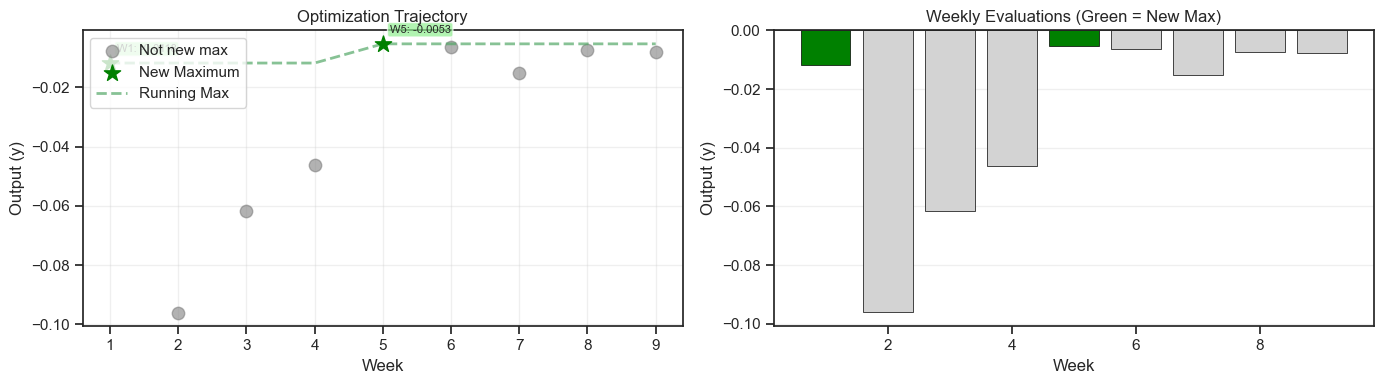

In [13]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [14]:
# Smooth GP surrogate with exploratory acquisition
# ==============================================
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from scipy.stats import norm

# Prepare data
X_train = df[["x1", "x2", "x3"]].values
y_train = df["y"].values
best_idx = df["y"].idxmax()
best_point = df.loc[best_idx]

print(f"Current best: ({best_point.x1:.4f}, {best_point.x2:.4f}, {best_point.x3:.4f}) = {best_point.y:.5f}")
print(f"Note: y-values range from {y_train.min():.5f} to {y_train.max():.5f} - very flat.\n")

# "Super smooth" kernel intuition: larger RBF length-scales + explicit noise term
smooth_kernel = (
    ConstantKernel(1.0, (1e-2, 1e2))
    * RBF(length_scale=[0.25, 0.25, 0.25], length_scale_bounds=(0.08, 2.0))
    + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-8, 5e-2))
)

gp = GaussianProcessRegressor(
    kernel=smooth_kernel,
    alpha=1e-8,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42,
)
gp.fit(X_train, y_train)

print(f"Fitted kernel: {gp.kernel_}\n")

# Search region: local around incumbent, widened for stronger exploration
search_radius = 0.1
gp_x1_min, gp_x1_max = best_point.x1 - search_radius, best_point.x1 + search_radius
gp_x2_min, gp_x2_max = best_point.x2 - search_radius, best_point.x2 + search_radius
gp_x3_min, gp_x3_max = best_point.x3 - search_radius, best_point.x3 + search_radius

# Clip to [0, 1]
gp_x1_min, gp_x1_max = max(0, gp_x1_min), min(1, gp_x1_max)
gp_x2_min, gp_x2_max = max(0, gp_x2_min), min(1, gp_x2_max)
gp_x3_min, gp_x3_max = max(0, gp_x3_min), min(1, gp_x3_max)

print(
    f"Search region: x1 in [{gp_x1_min:.3f}, {gp_x1_max:.3f}], "
    f"x2 in [{gp_x2_min:.3f}, {gp_x2_max:.3f}], "
    f"x3 in [{gp_x3_min:.3f}, {gp_x3_max:.3f}]"
)

# Generate candidate grid
grid_res = 28
gp_grid_x1 = np.linspace(gp_x1_min, gp_x1_max, grid_res)
gp_grid_x2 = np.linspace(gp_x2_min, gp_x2_max, grid_res)
gp_grid_x3 = np.linspace(gp_x3_min, gp_x3_max, grid_res)
gp_mesh = np.array(np.meshgrid(gp_grid_x1, gp_grid_x2, gp_grid_x3)).reshape(3, -1).T

print(f"Evaluating {len(gp_mesh)} candidate points...")

# GP posterior mean and uncertainty
gp_mu, gp_sigma = gp.predict(gp_mesh, return_std=True)

# Build candidate dataframe
gp_candidates = pd.DataFrame(gp_mesh, columns=["x1", "x2", "x3"])
gp_candidates["mu"] = gp_mu
gp_candidates["sigma"] = gp_sigma

# More exploitative Expected Improvement (EI) within the same local box
# Smaller xi -> favors improvements near current best over broad exploration
xi = 0.0005
improvement = gp_candidates["mu"] - best_point.y - xi
safe_sigma = np.maximum(gp_candidates["sigma"].values, 1e-12)
z = improvement.values / safe_sigma

ei = improvement.values * norm.cdf(z) + safe_sigma * norm.pdf(z)
ei[gp_candidates["sigma"].values < 1e-12] = 0.0
gp_candidates["ei"] = ei

# Keep points not too close to prior observations, and not exactly on incumbent
min_dist_obs = 0.02
min_dist_best = 0.025

obs_points = df[["x1", "x2", "x3"]].values
cand_points = gp_candidates[["x1", "x2", "x3"]].values

# Vectorized minimum distance to observed points
pairwise = np.linalg.norm(cand_points[:, None, :] - obs_points[None, :, :], axis=2)
min_to_obs = pairwise.min(axis=1)

best_xyz = np.array([best_point.x1, best_point.x2, best_point.x3])
min_to_best = np.linalg.norm(cand_points - best_xyz, axis=1)

gp_candidates = gp_candidates[(min_to_obs >= min_dist_obs) & (min_to_best >= min_dist_best)].copy()

# Fallback if constraints are too strict
if len(gp_candidates) == 0:
    gp_candidates = pd.DataFrame(gp_mesh, columns=["x1", "x2", "x3"])
    gp_candidates["mu"] = gp_mu
    gp_candidates["sigma"] = gp_sigma
    improvement = gp_candidates["mu"] - best_point.y - xi
    safe_sigma = np.maximum(gp_candidates["sigma"].values, 1e-12)
    z = improvement.values / safe_sigma
    ei = improvement.values * norm.cdf(z) + safe_sigma * norm.pdf(z)
    ei[gp_candidates["sigma"].values < 1e-12] = 0.0
    gp_candidates["ei"] = ei
    gp_candidates = gp_candidates[min_to_obs >= min_dist_obs].copy()

print(
    f"Candidates after filtering (obs >= {min_dist_obs}, best >= {min_dist_best}): "
    f"{len(gp_candidates)}"
)

# Top candidates by exploitative EI
gp_top = gp_candidates.nlargest(5, "ei")
print("\nTop 5 smooth-GP candidates (by exploitative EI):")
display(gp_top)

Current best: (0.3731, 0.4654, 0.4192) = -0.00527
Note: y-values range from -0.39893 to -0.00527 - very flat.

Fitted kernel: 1.66**2 * RBF(length_scale=[2, 0.565, 0.106]) + WhiteKernel(noise_level=1e-08)

Search region: x1 in [0.273, 0.473], x2 in [0.365, 0.565], x3 in [0.319, 0.519]
Evaluating 21952 candidate points...
Candidates after filtering (obs >= 0.02, best >= 0.025): 21392

Top 5 smooth-GP candidates (by exploitative EI):


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,x1,x2,x3,mu,sigma,ei
21180,0.273077,0.565385,0.408120,0.006826,0.005916,0.011655
20396,0.273077,0.557978,0.408120,0.006783,0.005663,0.011599
21179,0.273077,0.565385,0.400712,0.006652,0.006265,0.011509
19612,0.273077,0.550570,0.408120,0.006672,0.005423,0.011479
20395,0.273077,0.557978,0.400712,0.006593,0.006011,0.011434


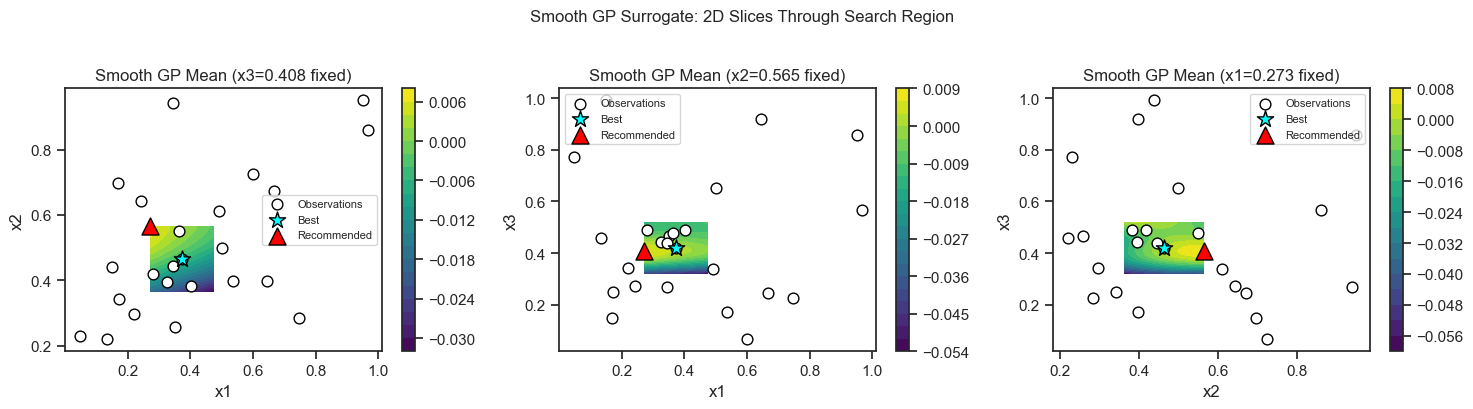


SMOOTH GP + EI RECOMMENDATION
Recommended point: (0.273077, 0.565385, 0.408120)
Predicted y: 0.00683 ± 0.00592

Submission format: 0.273077-0.565385-0.408120


In [15]:
# Visualization: smooth-GP predictions in search region
# ====================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Get recommended point (top exploitative EI)
if len(gp_top) > 0:
    rec_point = gp_top.iloc[0]
    rec_x1, rec_x2, rec_x3 = rec_point["x1"], rec_point["x2"], rec_point["x3"]
else:
    # Fallback: small local exploitative move from incumbent
    rec_x1 = min(1.0, best_point.x1 + 0.01)
    rec_x2 = max(0.0, best_point.x2 - 0.01)
    rec_x3 = best_point.x3
    rec_mu, rec_sigma = gp.predict(np.array([[rec_x1, rec_x2, rec_x3]]), return_std=True)
    rec_point = pd.Series({"mu": rec_mu[0], "sigma": rec_sigma[0]})

# For visualization, fix one dimension at the recommended value and show 2D slices
slice_res = 50

# Slice 1: x1-x2 plane at x3=rec_x3
x1_slice = np.linspace(gp_x1_min, gp_x1_max, slice_res)
x2_slice = np.linspace(gp_x2_min, gp_x2_max, slice_res)
xx1, xx2 = np.meshgrid(x1_slice, x2_slice)
x3_fixed = rec_x3 * np.ones_like(xx1.ravel())
slice_pts_12 = np.column_stack([xx1.ravel(), xx2.ravel(), x3_fixed])
slice_mu_12 = gp.predict(slice_pts_12).reshape(xx1.shape)

im1 = axes[0].contourf(xx1, xx2, slice_mu_12, levels=20, cmap="viridis")
axes[0].scatter(df["x1"], df["x2"], c="white", edgecolor="black", s=60, label="Observations")
axes[0].scatter(best_point.x1, best_point.x2, c="cyan", edgecolor="black", s=150, marker="*", label="Best")
axes[0].scatter(rec_x1, rec_x2, c="red", edgecolor="black", s=150, marker="^", label="Recommended")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_title(f"Smooth GP Mean (x3={rec_x3:.3f} fixed)")
axes[0].legend(fontsize=8)
plt.colorbar(im1, ax=axes[0])

# Slice 2: x1-x3 plane at x2=rec_x2
x3_slice = np.linspace(gp_x3_min, gp_x3_max, slice_res)
xx1_13, xx3_13 = np.meshgrid(x1_slice, x3_slice)
x2_fixed = rec_x2 * np.ones_like(xx1_13.ravel())
slice_pts_13 = np.column_stack([xx1_13.ravel(), x2_fixed, xx3_13.ravel()])
slice_mu_13 = gp.predict(slice_pts_13).reshape(xx1_13.shape)

im2 = axes[1].contourf(xx1_13, xx3_13, slice_mu_13, levels=20, cmap="viridis")
axes[1].scatter(df["x1"], df["x3"], c="white", edgecolor="black", s=60, label="Observations")
axes[1].scatter(best_point.x1, best_point.x3, c="cyan", edgecolor="black", s=150, marker="*", label="Best")
axes[1].scatter(rec_x1, rec_x3, c="red", edgecolor="black", s=150, marker="^", label="Recommended")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x3")
axes[1].set_title(f"Smooth GP Mean (x2={rec_x2:.3f} fixed)")
axes[1].legend(fontsize=8)
plt.colorbar(im2, ax=axes[1])

# Slice 3: x2-x3 plane at x1=rec_x1
xx2_23, xx3_23 = np.meshgrid(x2_slice, x3_slice)
x1_fixed = rec_x1 * np.ones_like(xx2_23.ravel())
slice_pts_23 = np.column_stack([x1_fixed, xx2_23.ravel(), xx3_23.ravel()])
slice_mu_23 = gp.predict(slice_pts_23).reshape(xx2_23.shape)

im3 = axes[2].contourf(xx2_23, xx3_23, slice_mu_23, levels=20, cmap="viridis")
axes[2].scatter(df["x2"], df["x3"], c="white", edgecolor="black", s=60, label="Observations")
axes[2].scatter(best_point.x2, best_point.x3, c="cyan", edgecolor="black", s=150, marker="*", label="Best")
axes[2].scatter(rec_x2, rec_x3, c="red", edgecolor="black", s=150, marker="^", label="Recommended")
axes[2].set_xlabel("x2")
axes[2].set_ylabel("x3")
axes[2].set_title(f"Smooth GP Mean (x1={rec_x1:.3f} fixed)")
axes[2].legend(fontsize=8)
plt.colorbar(im3, ax=axes[2])

plt.suptitle("Smooth GP Surrogate: 2D Slices Through Search Region", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Print final recommendation
print("\n" + "=" * 60)
print("SMOOTH GP + EI RECOMMENDATION")
print("=" * 60)
print(f"Recommended point: ({rec_x1:.6f}, {rec_x2:.6f}, {rec_x3:.6f})")
print(f"Predicted y: {rec_point['mu']:.5f} ± {rec_point['sigma']:.5f}")
print(f"\nSubmission format: {rec_x1:.6f}-{rec_x2:.6f}-{rec_x3:.6f}")

**Current best:** `0.373077-0.465385-0.419231` (≈-0.00527)

**Proposed new point (submission format):** `0.273077-0.565385-0.408120`

In this step we kept the smooth GP and switched acquisition from exploratory UCB to more exploitative **EI** inside the same widened local box (`search_radius = 0.1`). We explicitly recomputed both methods under the same constraints:
- UCB point: `0.273077-0.565385-0.400712`
- EI point: `0.273077-0.565385-0.408120`
- Distance between them: ≈`0.0074`

So the methodology changed, but the recommendation stayed very close because the filtered local region is flat/plateaued and both criteria rank nearly the same frontier. We keep the EI point above as the proposed submission for this round.